In [12]:
%load_ext autoreload
%autoreload 2

import glob, h5py, math, time, os, json
from scipy.stats import norm, expon, chi2, uniform, chisquare, gamma
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

import sys  
sys.path.insert(1, '../utils/')
import new_nplm as nplm
from ANALYSISutils import plot_2distribution

sys.path.append("../..")
from utils.plotting import make_corner
from utils import plotting

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
# hyper parameters of the NPLM model
M=100 # number of kernels
flk_sigmas = [0.1, 1.5, 2.6, 3.6, 4.9, 9.8] # values of kernel's width used for multiple testing
flk_sigma_maps = [str(k) for k in np.arange(len(flk_sigmas))]

# files containing the toys for different physics assumptions
# keep 'ref' as key for the calibraiton toys for consistence
base_dir = "../experiments_output/phil_toy/latent"
files_dict = {
    #'ref': f"{base_dir}/Nref8000_Nbkg1000_refOnly/tests_all.h5",
    'ref': f"{base_dir}/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig0/tests_all.h5",
    0.0125: f"{base_dir}/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig25_3/tests_all.h5",
    0.025: f"{base_dir}/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig50_3/tests_all.h5",
    0.05: f"{base_dir}/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig100_3/tests_all.h5",
    0.1: f"{base_dir}/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig200_3/tests_all.h5",
}
# key values extraction
files = list(files_dict.values())
labels_list = list(files_dict.keys())
inj_fractions = sorted([k for k in files_dict.keys() if k != 'ref'])

NTOYS = 500
tstat_dict = {}
i=0
for f5 in files:
    f = h5py.File(f5, 'r')
    tstat_dict[labels_list[i]] = []
    for flk_sigma in flk_sigma_maps:
        key = str(flk_sigma)
        if len(f[key]) < NTOYS:
            print("not enough toys in",f5,key)
        tstat_dict[labels_list[i]].append(np.array(f[key])[:NTOYS].reshape(-1,1))
    tstat_dict[labels_list[i]] = np.concatenate(tstat_dict[labels_list[i]],axis=1)
    f.close()
    i+=1

file = np.load("/n/home11/sambt/phlab-neurips25/experiments/philToy/philToy_idealZscores_sig4_disc4_rand4_seed2maha_toys_disc.npz")
ideal_zscores = {"zscores":file["toymc"],"fracs":file["toyxy"]/2000}
double_ideal_zscores = {"zscores":file["toyfmc"],"fracs":file["toyxy"]/2000}
#ideal_zscores = np.load("/n/home11/sambt/phlab-neurips25/experiments/jetclass/jetClass_T0.1_idealZscores_LRtestWithFit_nbkg10k.npz")
#double_ideal_zscores = np.load("/n/home11/sambt/phlab-neurips25/experiments/jetclass/jetClassWithHbb_T0.1_idealZscores_LRtestWithFit_nbkg10k.npz")
maha_emp_zscores = np.load("/n/home11/sambt/phlab-neurips25/nplm/notebooks_maha/philToy_latent_rand4_maha_empiricalZscore.npz")

In [14]:
pX  =file["toyxy"]/2000
pYN =file["toymc"]
pYNE=file["toymce"]
pYF =file["toyfmc"]
pYFE=file["toyfmce"]

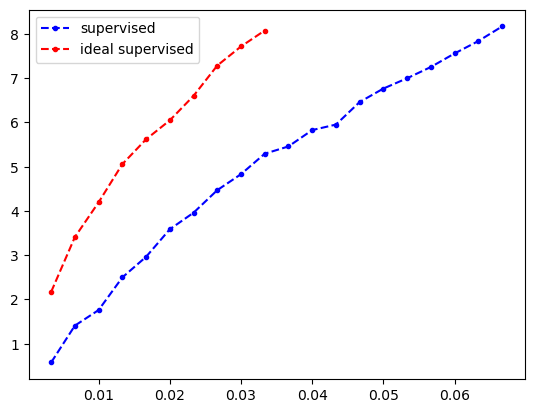

In [15]:
plt.plot(pX,pYN,c='b',marker='.',linestyle='--',label='supervised')
plt.plot(pX,pYF,c='r',marker='.',linestyle='--',label='ideal supervised')
plt.legend()
plt.show()        

In [16]:
pvalues = {}
pvalues_min = {}
pvalues_avg = {}
pvalues_prod = {}
z_obs = {}
z_obs_p = {}
z_obs_m = {}
z_emp = {}
z_emp_p = {}
z_emp_m = {}
z_min = {}
z_avg = {}
z_prod = {}
i=0
for key in list(tstat_dict.keys()):
    pvalues[key] = []
    z_obs[key] = []
    z_obs_p[key] = []
    z_obs_m[key] = []
    z_emp[key] = []
    z_emp_p[key] = []
    z_emp_m[key] = []
    for isigma,flk_sigma in enumerate(flk_sigmas):
        t1 = tstat_dict['ref'][:,isigma]
        t1[np.isnan(t1)]=np.zeros_like(t1[np.isnan(t1)])
        
        t2 = tstat_dict[key][:,isigma]
        t2[np.isnan(t2)]=np.zeros_like(t2[np.isnan(t2)])
        
        z_obs_val, z_emp_val = nplm.get_zScores(t1, t2, df=np.mean(t1))
                
        pvalues[key].append(chi2.sf(t2, df=np.median(t1)).reshape(-1,1))
        
        z_obs[key].append(np.array([z_obs_val[0]]).reshape(1,1))
        z_obs_p[key].append(np.array([z_obs_val[1]]).reshape(1,1))
        z_obs_m[key].append(np.array([z_obs_val[2]]).reshape(1,1))
        
        z_emp[key].append(np.array([z_emp_val[0]]).reshape(1,1))
        z_emp_p[key].append(np.array([z_emp_val[1]]).reshape(1,1))
        z_emp_m[key].append(np.array([z_emp_val[2]]).reshape(1,1))
        
    i+=1
    pvalues[key] = np.concatenate(pvalues[key],axis=1)
    z_obs[key] = np.concatenate(z_obs[key],axis=1)
    z_obs_p[key] = np.concatenate(z_obs_p[key],axis=1)
    z_obs_m[key] = np.concatenate(z_obs_m[key],axis=1)
    z_emp[key] = np.concatenate(z_emp[key],axis=1)
    z_emp_p[key] = np.concatenate(z_emp_p[key],axis=1)
    z_emp_m[key] = np.concatenate(z_emp_m[key],axis=1)
    
    # compute mins/prods/means over all kernel sizes
    t1 = tstat_dict['ref']
    t1[np.isnan(t1)]=np.zeros_like(t1[np.isnan(t1)])
    t2 = tstat_dict[key]
    t2[np.isnan(t2)]=np.zeros_like(t2[np.isnan(t2)])
    
    p_min_ref, p_min_data = nplm.NPLM_combined_pval(t1,t2,rule='min')
    p_avg_ref, p_avg_data = nplm.NPLM_combined_pval(t1,t2,rule='avg')
    p_prod_ref, p_prod_data = nplm.NPLM_combined_pval(t1,t2,rule='prod')
    
    pvalues_min[key] = p_min_data
    pvalues_avg[key] = p_avg_data
    pvalues_prod[key] = p_prod_data
    
    z_min[key] = nplm.z_emp(p_min_ref,p_min_data)
    z_avg[key] = nplm.z_emp(p_avg_ref,p_avg_data)
    z_prod[key] = nplm.z_emp(p_prod_ref,p_prod_data)

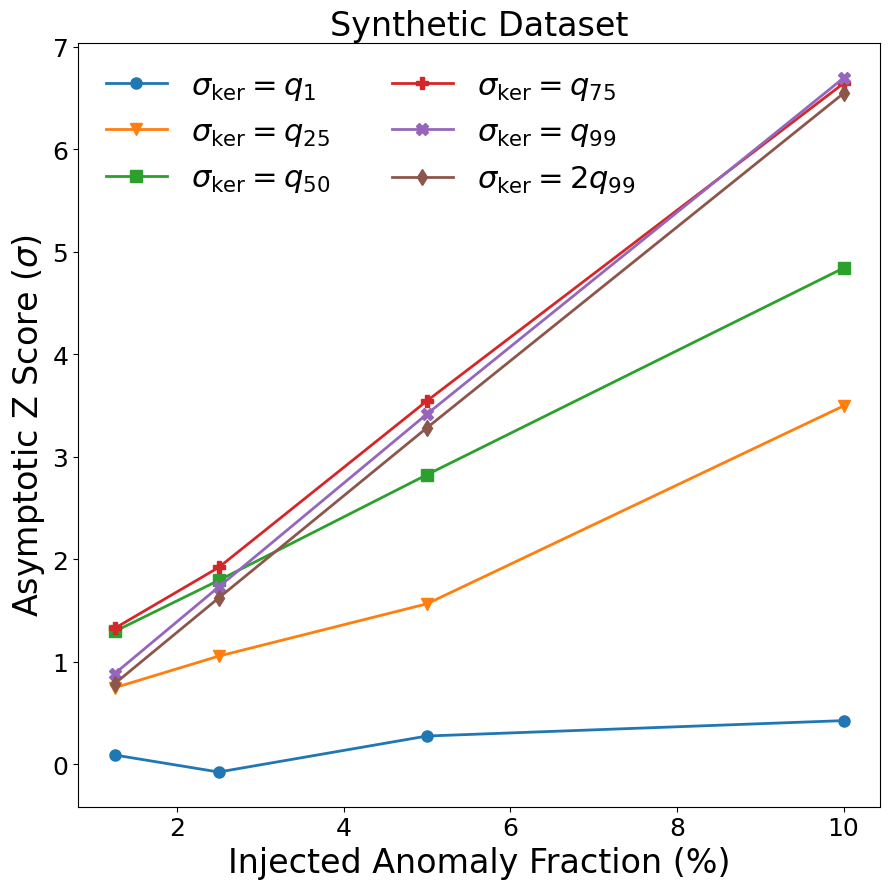

In [17]:
plt.figure(figsize=(9,9))
plt.title(r"Synthetic Dataset",fontsize=24)
x_values = [100*f for f in inj_fractions]
markers = ['o','v','s','P','X','d']
for isigma,sigma in enumerate(flk_sigmas):
    y_values = [z_obs[f][:,isigma] for f in inj_fractions]
    plt.plot(x_values,y_values,lw=2,
             marker=markers[isigma],markersize=8,
             color=f"C{isigma}",
             #label=f"$\sigma_\\text{{ker}} = {sigma:.1f}$")
             label=plotting.kernel_to_label[sigma])
#plt.xscale('log')
xlim = plt.gca().get_xlim()
#plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],lw=2,linestyle='--',color='blue',label='Supervised')
#plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],lw=2,linestyle='--',color='crimson',label='Ideal Supervised')
#plt.xlim(xlim)
#plt.xlim([0,20])
#plt.ylim([0,10])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Asymptotic Z Score ($\sigma$)",fontsize=24)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=24)
plt.legend(ncol=2,fontsize=22,frameon=False)
plt.tight_layout()
plt.savefig("toy_asymptoticZscores.pdf",bbox_inches='tight')

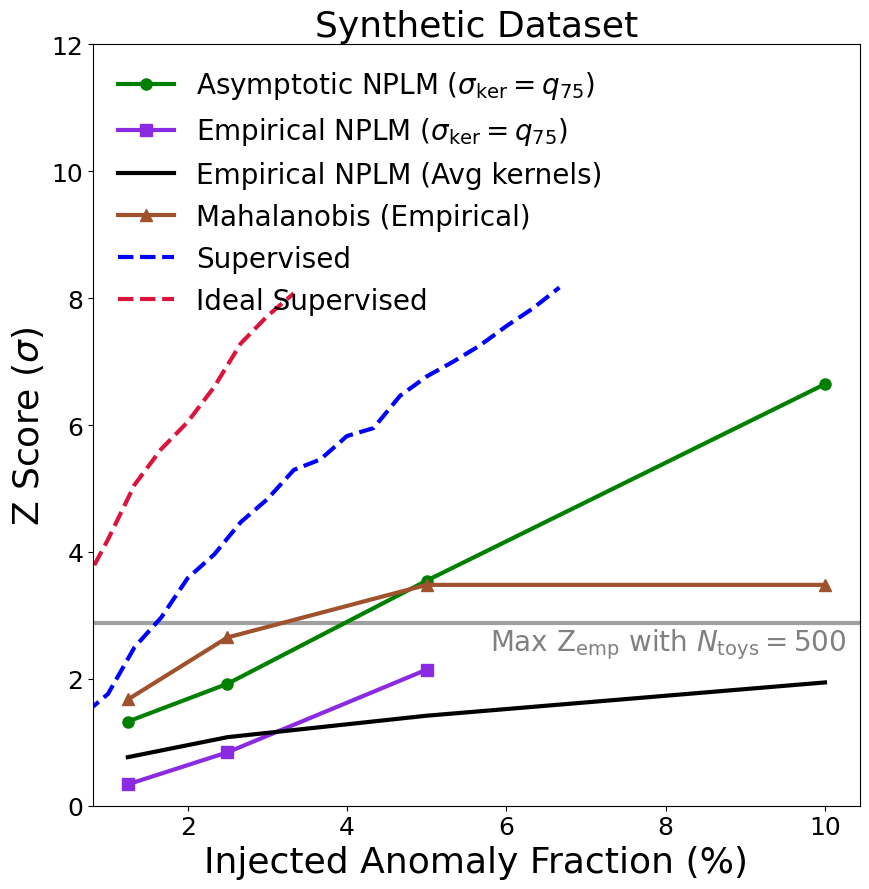

In [18]:
plt.figure(figsize=(9,9))
plt.title(r"Synthetic Dataset",fontsize=26)
x_values = [100*f for f in inj_fractions]

best_sigma = 3.6
isigma = flk_sigmas.index(best_sigma)
handles_1=[]
sigma_label = plotting.kernel_to_label[best_sigma]

# asymptotic
y_values = [z_obs[f][:,isigma] for f in inj_fractions]
l1,=plt.plot(x_values,y_values,lw=3,
         marker='o',markersize=8,color='green',
         #label=f"Asymptotic NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
         label=f"Asymptotic NPLM ({sigma_label})")
handles_1.append(l1)

#empirical
CUTOFF = -1
y_values = [z_emp[f][:,isigma] for f in inj_fractions]
l2,=plt.plot(x_values[:CUTOFF],y_values[:CUTOFF],lw=3,
         marker='s',markersize=8,color='blueviolet',
         #label=f"Empirical NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
         label=f"Empirical NPLM ({sigma_label})")
handles_1.append(l2)

CUTOFF = None
# empirical average
l3,=plt.plot(x_values[:CUTOFF],[z_avg[f] for f in inj_fractions][:CUTOFF],lw=3, linestyle='-',
         marker=None,color="k",label=f"Empirical NPLM (Avg kernels)")
handles_1.append(l3)

# maha
l7, = plt.plot(100*maha_emp_zscores['fracs'],maha_emp_zscores['zscores'],lw=3,color='sienna',label="Mahalanobis (Empirical)",
              marker='^',markersize=8)
handles_1.append(l7)

xlim = plt.gca().get_xlim()
l4,=plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],
         lw=3,linestyle='--',color='blue',label='Supervised')
handles_1.append(l4)
l5,=plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],
         lw=3,linestyle='--',color='crimson',label='Ideal Supervised')
handles_1.append(l5)

l6= plt.axhline(norm.ppf(1-1./NTOYS),lw=3,linestyle='-',color='gray',zorder=0,label=f"Max Z with $N_\\text{{toys}} = 500$",alpha=0.75)
handles_2 = [l6]

plt.xlim(xlim)
#plt.xlim([0.,2])
plt.ylim([0,12])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Z Score ($\sigma$)",fontsize=26)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=26)
#plt.grid(axis='y')
leg1 = plt.legend(handles=handles_1,ncol=1,fontsize=20,frameon=False,loc='upper left')
#leg2 = plt.legend(handles=handles_2,ncol=1,fontsize=20,frameon=False,loc='lower right')
#plt.gca().add_artist(leg1)
plt.text(5.8,2.45,f"Max Z$_\\text{{emp}}$ with $N_\\text{{toys}} = 500$",fontsize=20,color='gray')
plt.tight_layout()
plt.savefig("philToy_latent_rand4_Zsummary.pdf",bbox_inches='tight')

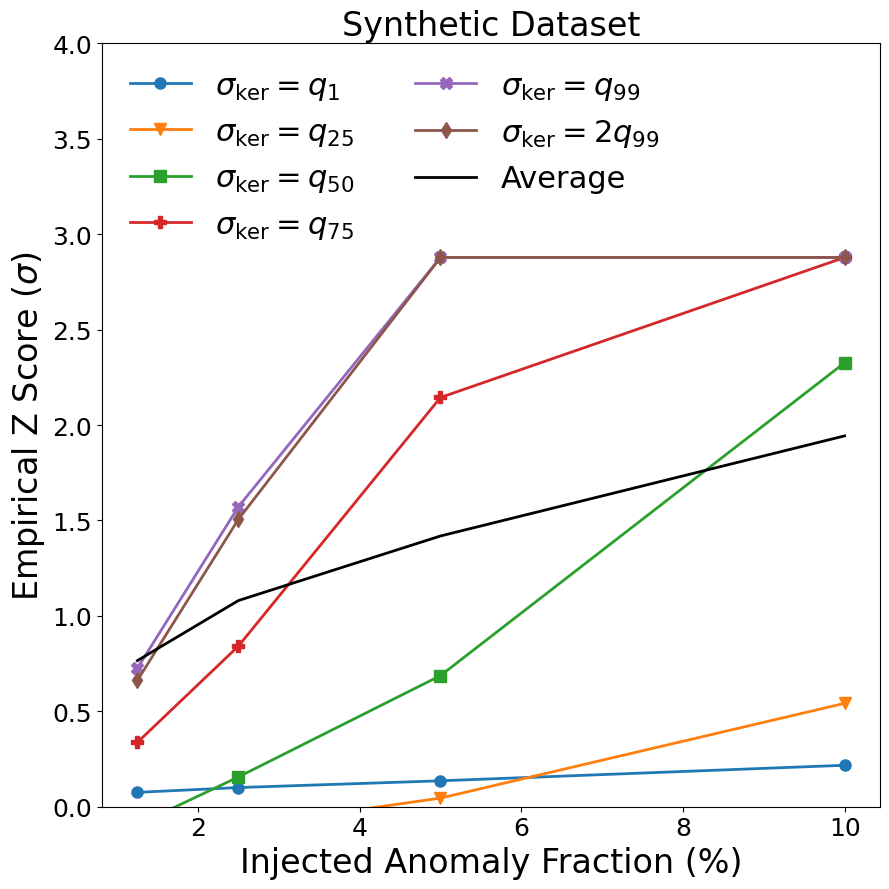

In [19]:
plt.figure(figsize=(9,9))
plt.title(r"Synthetic Dataset",fontsize=24)
x_values = [100*f for f in inj_fractions]
markers = ['o','v','s','P','X','d']
for isigma,sigma in enumerate(flk_sigmas):
    y_values = [z_emp[f][:,isigma] for f in inj_fractions]
    plt.plot(x_values,y_values,lw=2,
             marker=markers[isigma],markersize=8,
             color=f"C{isigma}",
             #label=f"$\sigma_\\text{{ker}} = {sigma:.1f}$")
             label=plotting.kernel_to_label[sigma])
#plt.plot(x_values,[z_min[f] for f in inj_fractions],lw=2, marker=None,color="k",label=f"Min Aggregation")
plt.plot(x_values,[z_avg[f] for f in inj_fractions],lw=2, linestyle='-',marker=None,color="k",label=f"Average")
#plt.plot(x_values,[z_prod[f] for f in inj_fractions],lw=2, linestyle='--',marker=None,color="k",label=f"Prod Aggregation")
#plt.xscale('log')
plt.ylim([0,4])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Empirical Z Score ($\sigma$)",fontsize=24)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=24)
plt.legend(ncol=2,fontsize=22,frameon=False,loc='upper left')
plt.tight_layout()
plt.savefig("toy_empiricalZ.pdf",bbox_inches='tight')

# scan of nsig

In [73]:
# hyper parameters of the NPLM model
M=100 # number of kernels
flk_sigmas = [0.1, 1.5, 2.6, 3.6, 4.9, 9.8] # values of kernel's width used for multiple testing
flk_sigma_maps = [str(k) for k in np.arange(len(flk_sigmas))]

# files containing the toys for different physics assumptions
# keep 'ref' as key for the calibraiton toys for consistence
base_dir = "/n/home11/sambt/phlab-neurips25/nplm/experiments_output/phil_toy/scan_nsig/"
files_dict = {
    "ref_rand0":f"{base_dir}/raw_sig4_disc4_rand0_seed2/NPLM-multiple-test/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig0/tests_all.h5",
    "100_rand0":f"{base_dir}/raw_sig4_disc4_rand0_seed2/NPLM-multiple-test/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig100_3/tests_all.h5",
    "ref_rand16":f"{base_dir}/raw_sig4_disc4_rand16_seed2/NPLM-multiple-test/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig0/tests_all.h5",
    "100_rand16":f"{base_dir}/raw_sig4_disc4_rand16_seed2/NPLM-multiple-test/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig100_3/tests_all.h5",
    "ref_rand2":f"{base_dir}/raw_sig4_disc4_rand2_seed2/NPLM-multiple-test/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig0/tests_all.h5",
    "100_rand2":f"{base_dir}/raw_sig4_disc4_rand2_seed2/NPLM-multiple-test/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig100_3/tests_all.h5",
    "ref_rand4":f"{base_dir}/raw_sig4_disc4_rand4_seed2/NPLM-multiple-test/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig0/tests_all.h5",
    "100_rand4":f"{base_dir}/raw_sig4_disc4_rand4_seed2/NPLM-multiple-test/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig100_3/tests_all.h5",
    "ref_rand8":f"{base_dir}/raw_sig4_disc4_rand8_seed2/NPLM-multiple-test/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig0/tests_all.h5",
    "100_rand8":f"{base_dir}/raw_sig4_disc4_rand8_seed2/NPLM-multiple-test/M110_lam1e-06_iter10000000.0Nref10000_Nbkg2000_Nsig100_3/tests_all.h5"
}
# key values extraction
#files = list(files_dict.values())
#labels_list = list(files_dict.keys())
#inj_fractions = sorted([k for k in files_dict.keys() if k != 'ref'])

NTOYS = 500
tstat_dict = {}
i=0
for key,f5 in files_dict.items():
    f = h5py.File(f5, 'r')
    tstat_dict[key] = []
    for flk_sigma in flk_sigma_maps:
        k = str(flk_sigma)
        if len(f[k]) < NTOYS:
            print("not enough toys in",f5,key)
        tstat_dict[key].append(np.array(f[k])[:NTOYS].reshape(-1,1))
    tstat_dict[key] = np.concatenate(tstat_dict[key],axis=1)
    f.close()
    i+=1

#file = np.load("/n/home11/sambt/phlab-neurips25/experiments/philToy/philToy_idealZscores_sig4_disc4_rand4_seed2maha_toys_disc.npz")
#ideal_zscores = {"zscores":file["toymc"],"fracs":file["toyxy"]/2000}
#double_ideal_zscores = {"zscores":file["toyfmc"],"fracs":file["toyxy"]/2000}
#ideal_zscores = np.load("/n/home11/sambt/phlab-neurips25/experiments/jetclass/jetClass_T0.1_idealZscores_LRtestWithFit_nbkg10k.npz")
#double_ideal_zscores = np.load("/n/home11/sambt/phlab-neurips25/experiments/jetclass/jetClassWithHbb_T0.1_idealZscores_LRtestWithFit_nbkg10k.npz")
#maha_emp_zscores = np.load("/n/home11/sambt/phlab-neurips25/nplm/notebooks_maha/philToy_latent_rand4_maha_empiricalZscore.npz")

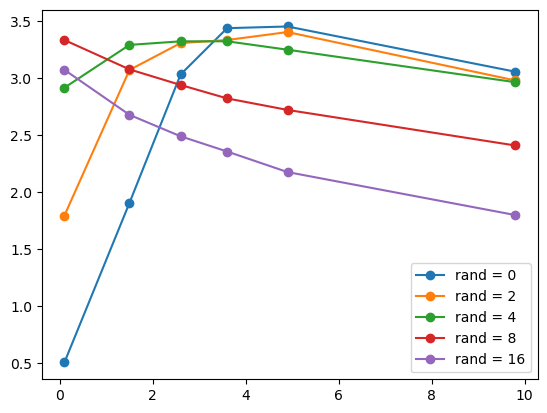

In [74]:
rand_dims = [0,2,4,8,16]
asymp_zscores = []
for r in rand_dims:
    zs = []
    for i,sigma in enumerate(flk_sigmas):
        tref = tstat_dict[f'ref_rand{r}'][:,i]
        tref[np.isnan(tref)] = 0
        
        td = tstat_dict[f'100_rand{r}'][:,i]
        td[np.isnan(td)] = 0
        
        z_obs_val, z_emp_val = nplm.get_zScores(tref, td, df=np.mean(tref))
        zs.append(z_obs_val[0])
    plt.plot(flk_sigmas,zs,label=f"rand = {r}",marker='o')
plt.legend()

In [90]:
sigma = 3.6
isigma = flk_sigmas.index(sigma)
rand_dims = [0,2,4,8,16]
zscores = []
zscores_emp = []
for r in rand_dims:
    tref = tstat_dict[f'ref_rand{r}'][:,isigma]
    tref[np.isnan(tref)] = 0

    td = tstat_dict[f'100_rand{r}'][:,isigma]
    td[np.isnan(td)] = 0

    z_obs_val, z_emp_val = nplm.get_zScores(tref, td, df=np.mean(tref))
    zscores.append(z_obs_val[0])
    zscores_emp.append(z_emp_val[0])

In [91]:
fscan = np.load("/n/home11/sambt/phlab-neurips25/experiments/philToy/philToy_nsigScan_emperical.npz")

xscan = np.arange(20)
raw = []
nn = []
full = []
disc = []
for x in xscan:
    idx = list(fscan[f'rand{x}x']).index(100)
    nn.append(fscan[f"rand{x}ynn"][idx])
    raw.append(fscan[f"rand{x}yraw"][idx])
    full.append(fscan[f"rand{x}yfull"][idx])
    disc.append(fscan[f"rand{x}ydisc"][idx])

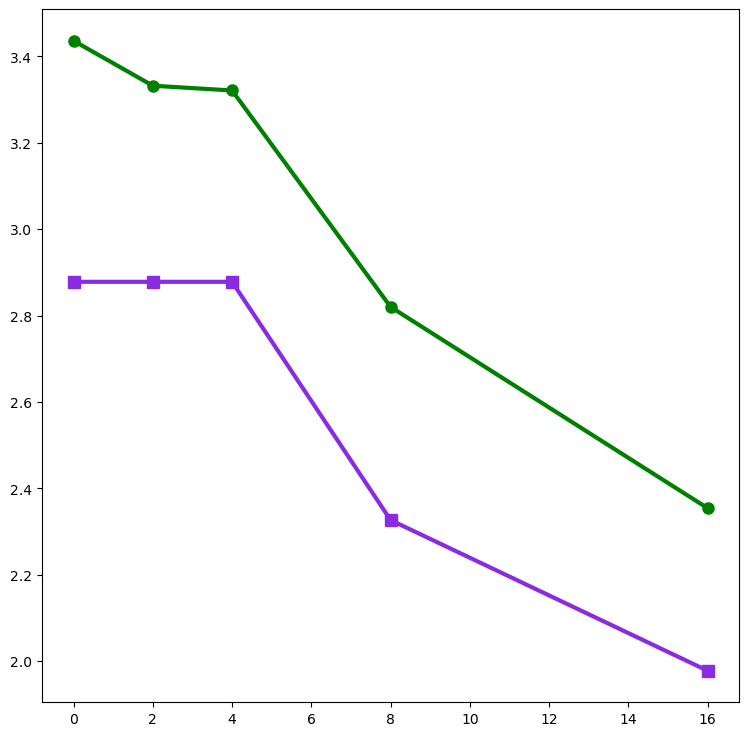

In [94]:
plt.figure(figsize=(9,9))

plt.plot(rand_dims,zscores,lw=3,
         marker='o',markersize=8,color='green',
         label=f"Asymptotic NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")

l2,=plt.plot(rand_dims,zscores_emp,lw=3,
         marker='s',markersize=8,color='blueviolet',
         label=f"Empirical NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")

In [97]:
1-norm.cdf(5)

2.866515719235352e-07